# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram


import lightgbm as lgb
import xgboost as xgb

import importlib
import bootstrap
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *

print("Modules reloaded successfully!")


Modules reloaded successfully!


In [3]:
# # Quick diagnostic - check what's installed
# import sys
# print(f"Python: {sys.executable}")

# packages = ['pandas', 'numpy', 'matplotlib', 'scipy', 'sklearn', 'xgboost', 'shap', 'joblib', 'tqdm', 'statsmodels', 'seaborn']
# for pkg in packages:
#     try:
#         mod = __import__(pkg)
#         version = getattr(mod, '__version__', 'unknown')
#         print(f"✓ {pkg:15s} {version}")
#     except ImportError:
#         print(f"✗ {pkg:15s} NOT INSTALLED")

In [4]:
golub = pd.read_csv('data/golub.csv')
golub.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [5]:
golub['Source'].value_counts()

Source
DFCI       44
CALGB      15
St-Jude     8
CCG         5
Name: count, dtype: int64

In [5]:
df = golub.copy()

df["Y"] = df["cancer"].replace({
    "allB": "ALL",
    "allT": "ALL",
    "aml": "AML"
})

print(df["Y"].value_counts())

Y
ALL    47
AML    25
Name: count, dtype: int64


In [6]:
gene_cols = golub.columns[golub.columns.get_loc("cancer") + 1:]
print(len(gene_cols))
print(gene_cols[:5])

7129
Index(['AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioB-3_at', 'AFFX-BioC-5_at',
       'AFFX-BioC-3_at'],
      dtype='object')


# Prepare data

In [7]:
y = df['Y'].map({"ALL": 0, "AML": 1})
# y = df['cancer'].map({"allB": 0, "allT": 1, "aml": 2})

print("Class distribution:")
print(y.value_counts().sort_index())

Class distribution:
Y
0    47
1    25
Name: count, dtype: int64


In [8]:
cat_cols = ["BM.PB", "Gender", "Source"]
# X = df[cat_cols + positive_feature_list].copy()
X = df[gene_cols.tolist()].copy()

# X[cat_cols] = X[cat_cols].astype("category")

In [9]:
# Check shapes before preprocessing
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# Ensure X and y have matching indices
assert len(X) == len(y), f"Length mismatch: X has {len(X)} samples, y has {len(y)} samples"
assert X.index.equals(y.index), "X and y have different indices"

print("\n✓ X and y shapes are consistent")

X shape: (72, 7129)
y shape: (72,)
y value counts:
Y
0    47
1    25
Name: count, dtype: int64

✓ X and y shapes are consistent


In [10]:
# Standardize gene columns
X_gene_standardized = df[gene_cols].copy()
scaler_genes = StandardScaler()
X_gene_standardized[gene_cols] = scaler_genes.fit_transform(X_gene_standardized[gene_cols])

In [19]:
X = X_gene_standardized

# Grouping

In [ ]:
# correlation_threshold = 0.7

In [11]:
# # --- Build distance matrix from absolute correlation ---
# abs_corr = X_gene_standardized.corr(method='pearson').abs()
# distance_matrix = 1 - abs_corr  # correlation 0.7 → distance 0.3

# # Ensure symmetry and zero diagonal (numerical safety)
# np.fill_diagonal(distance_matrix.values, 0)
# condensed_dist = squareform(distance_matrix.values, checks=False)

# # --- Hierarchical clustering with complete linkage ---
# Z = linkage(condensed_dist, method='complete')

# # --- Cut tree: distance threshold = 1 - correlation_threshold ---
# distance_threshold = 1 - correlation_threshold  # = 0.3

# labels = fcluster(Z, t=distance_threshold, criterion='distance')

# # --- Build result DataFrame ---
# gene_cluster_df = pd.DataFrame({
#     'gene': gene_cols,
#     'cluster': labels
# })

# # --- Verification: confirm all pairs within each cluster satisfy threshold ---
# violations = 0
# for cluster_id in gene_cluster_df['cluster'].unique():
#     genes_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
#     if len(genes_in_cluster) < 2:
#         continue
#     cluster_corr = abs_corr.loc[genes_in_cluster, genes_in_cluster]
#     min_corr = cluster_corr.values[np.triu_indices_from(cluster_corr.values, k=1)].min()
#     if min_corr < correlation_threshold:
#         violations += 1
#         print(f"  Cluster {cluster_id}: min pairwise correlation = {min_corr:.3f} ← VIOLATION")

# print(f"Violations: {violations}")  # Should always be 0

# # --- Summary stats ---
# cluster_sizes = gene_cluster_df['cluster'].value_counts()
# print(f"Correlation threshold:  {correlation_threshold}")
# print(f"Number of clusters:     {gene_cluster_df['cluster'].nunique()}")
# print(f"Mean cluster size:      {cluster_sizes.mean():.2f}")
# print(f"Median cluster size:    {cluster_sizes.median():.2f}")
# print(f"Max cluster size:       {cluster_sizes.max()}")
# print(f"Singletons:             {(cluster_sizes == 1).sum()}")
# print(f"Multi-gene clusters:    {(cluster_sizes > 1).sum()}")

In [14]:
# # --- Optional: visualize dendrogram ---
# plt.figure(figsize=(12, 5))
# dendrogram(Z, labels=gene_cols, leaf_rotation=90, color_threshold=distance_threshold)
# plt.axhline(y=distance_threshold, color='red', linestyle='--', label=f'Cut at d={distance_threshold}')
# plt.ylabel("Distance (1 - |correlation|)")
# plt.title("Gene Clustering Dendrogram (Complete Linkage)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [12]:
# # Create dictionary to store PC1 for each cluster
# cluster_pc1_dict = {}
# cluster_variance_explained = {}

# unique_clusters = gene_cluster_df['cluster'].unique()

# for cluster_id in unique_clusters:
#     # Get genes in this cluster
#     genes_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
    
#     # Extract data for these genes (samples x genes)
#     cluster_data = X_gene_standardized[genes_in_cluster]
    
#     if len(genes_in_cluster) == 1:
#         # For singleton
#         # s, use the gene itself as the representative
#         cluster_pc1_dict[cluster_id] = cluster_data.values.flatten()
#         cluster_variance_explained[cluster_id] = 1.0
#     else:
#         # Perform PCA
#         pca = PCA(n_components=1)
#         pc1 = pca.fit_transform(cluster_data)
        
#         # Store first principal component (flattened to 1D array)
#         cluster_pc1_dict[cluster_id] = pc1.flatten()
#         cluster_variance_explained[cluster_id] = pca.explained_variance_ratio_[0]

# # Create a dataframe with cluster representatives (samples x clusters)
# X_cluster_representatives = pd.DataFrame(cluster_pc1_dict)
# X_cluster_representatives.index = df.index

# print(f"Original gene features: {len(gene_cols)}")
# print(f"Cluster representatives (PC1): {X_cluster_representatives.shape[1]}")
# print(f"Dimensionality reduction: {len(gene_cols)} → {X_cluster_representatives.shape[1]}")
# print(f"\nVariance explained by PC1 (first 10 multi-gene clusters):")

# # Show variance explained for multi-gene clusters
# multi_gene_clusters = gene_cluster_df.groupby('cluster').size()
# multi_gene_clusters = multi_gene_clusters[multi_gene_clusters > 1].index

# for cluster_id in list(multi_gene_clusters)[:10]:
#     n_genes = len(gene_cluster_df[gene_cluster_df['cluster'] == cluster_id])
#     var_exp = cluster_variance_explained[cluster_id]
#     print(f"  Cluster {cluster_id} ({n_genes} genes): {var_exp:.3f}")

In [13]:
# # Correlation between cluster PC1 representatives
# pc1_corr = X_cluster_representatives.corr()
# print(f"Correlation matrix shape: {pc1_corr.shape} (clusters x clusters)")
# print(f"\nMean absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].mean():.4f}")
# print(f"Max absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].max():.4f}")

# # Display the correlation matrix
# pc1_corr

In [14]:
# # Create X_grouped with categorical columns and cluster PC1 representatives
# X_grouped = pd.concat([df[cat_cols], X_cluster_representatives], axis=1)
# # 
# # Convert all column names to strings (required by sklearn)
# X_grouped.columns = X_grouped.columns.astype(str)

# X_grouped[cat_cols] = X_grouped[cat_cols].astype("category")

# print(f"X_grouped shape: {X_grouped.shape}")
# print(f"  Categorical features: {len(cat_cols)}")
# print(f"  Cluster PC1 features: {X_cluster_representatives.shape[1]}")
# print(f"  Total features: {X_grouped.shape[1]}")
# print(f"\nColumn names preview:")
# print(f"  Cat cols: {cat_cols}")
# print(f"  First 5 cluster IDs: {X_grouped.columns[len(cat_cols):len(cat_cols)+5].tolist()}")

# X_grouped.head()

In [15]:
# # Create lookup function and reference for genes in each cluster
# def get_genes_in_cluster(cluster_id):
#     """Return list of genes in the specified cluster."""
#     genes = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
#     return genes

# # Create a dictionary for easy lookup
# cluster_to_genes = gene_cluster_df.groupby('cluster')['gene'].apply(list).to_dict()

# # Display function to show cluster details
# def show_cluster_info(cluster_id):
#     """Display detailed information about a cluster."""
#     genes = cluster_to_genes[cluster_id]
#     n_genes = len(genes)
#     var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
    
#     print(f"Cluster {cluster_id}:")
#     print(f"  Number of genes: {n_genes}")
#     print(f"  Variance explained by PC1: {var_exp}")
#     print(f"  Genes: {genes}")
#     return genes

In [16]:
# print("=" * 80)
# print("CLUSTER-TO-GENE MAPPING REFERENCE")
# print("=" * 80)
# print(f"\nTotal clusters: {len(cluster_to_genes)}")
# print(f"\nCluster size statistics:")
# cluster_sizes = gene_cluster_df.groupby('cluster').size()
# print(f"  Min: {cluster_sizes.min()}")
# print(f"  Max: {cluster_sizes.max()}")
# print(f"  Mean: {cluster_sizes.mean():.2f}")
# print(f"  Median: {cluster_sizes.median():.2f}")

# # Show the largest clusters
# print(f"\n{'='*80}")
# print("LARGEST CLUSTERS (Top 5)")
# print(f"{'='*80}")
# largest_clusters = cluster_sizes.nlargest(5).index

# for cluster_id in largest_clusters:
#     genes = cluster_to_genes[cluster_id]
#     var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
#     print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
#     print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")

# TreeSHAP Kernel Distribution Estimation 

See `model_wrapper.py` for the flexible ModelWrapper interface.

## LightGBM Model

In [18]:
# LightGBM parameters (similar structure to XGBoost)
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'learning_rate': 0.1,
    'max_depth': 8,
    'num_leaves': 31,
    'min_data_in_leaf': 15,
    'min_sum_hessian_in_leaf': 1e-3,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
    'deterministic': True,
    'num_threads': 1,
}


lgb_wrapper = create_model_wrapper(
    "lightgbm",
    params=lgb_params,
    num_boost_round=150
)

print("LightGBM wrapper created!")
print("Ready to train and evaluate")

LightGBM wrapper created!
Ready to train and evaluate


In [20]:
print("Training LightGBM model...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)


Training LightGBM model...
Training set: (57, 7129)
Test set: (15, 7129)


### Bootstrap with no screening

In [ ]:
# # lgb_boot_unscreen = boot_multi_repeat_inference_keep_all(
# lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
#     X=X,  # Use preprocessed data with one-hot encoded categoricals
#     y=y,
#     inner_variance="permutation",
#     task="binary",
#     n_bootstrap=1000,  
#     b_model=1, 
#     zero_tol=0,
#     model_wrapper=lgb_wrapper,  
#     n_jobs=6,        
#     show_progress=True
# )

# print(f"\nBootstrap complete! Generated {len(lgb_boot_unscreen)} results.")

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [11:45<00:00,  1.42it/s]


Bootstrap complete! Generated 1000 results.


In [26]:
# # Save — concat all 1000 small DataFrames into one
# os.makedirs("shap_results", exist_ok=True)

# pd.concat(lgb_boot_unscreen, ignore_index=True).to_parquet(
#     "shap_results/golub_unscreen_lgb.parquet",
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

In [25]:
df_all = pd.read_parquet("shap_results/golub_unscreen_lgb.parquet")
lgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(lgb_boot_unscreen)} bootstrap results")

Loaded 1000 bootstrap results


In [25]:
# lgb_mix_unscreen = estimate_sample_feature_distribution(lgb_boot_unscreen)

In [26]:
# top_df = plot_sample_top_features_overlay(
#     mix_df=lgb_mix_unscreen,
#     sample_id=0,
#     class_id=None,  # or class index for multiclass
#     top_k=15,
#     rank_by="mean_abs_estimated",
#     n_grid=600,
#     xlim=(-2, 4)
# )

In [27]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix_unscreen,
#     sample_id=0,
#     feature="5102",
#     # feature="M55150_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_unscreen,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [28]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix_unscreen,
#     sample_id=0,
#     feature="4519",
#     # feature="M23197_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_unscreen,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [27]:
# lgb_feature_kde_unscreen = estimate_feature_level_mixture_fast(
#     boot_results=lgb_boot_unscreen,
#     kernel="gaussian",
#     zero_tol=1e-8
# )

lgb_feature_kde_unscreen = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    zero_tol=1e-8
)

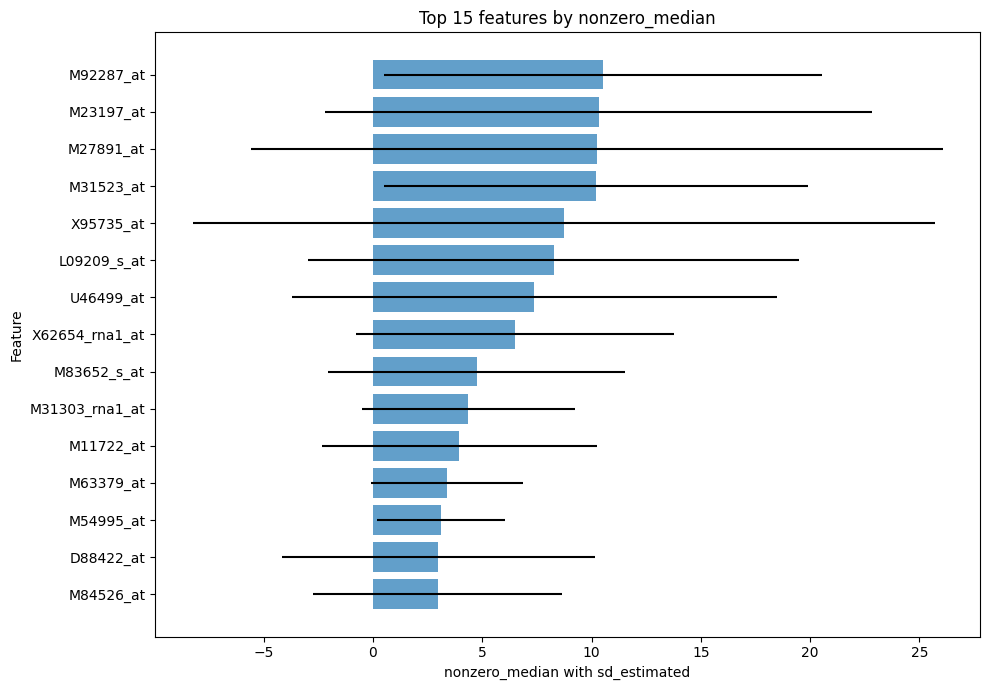

In [28]:
top_with_error = plot_top_feature_with_error(
    lgb_feature_kde_unscreen,
    top_k=15,
    score_col="nonzero_median",
)

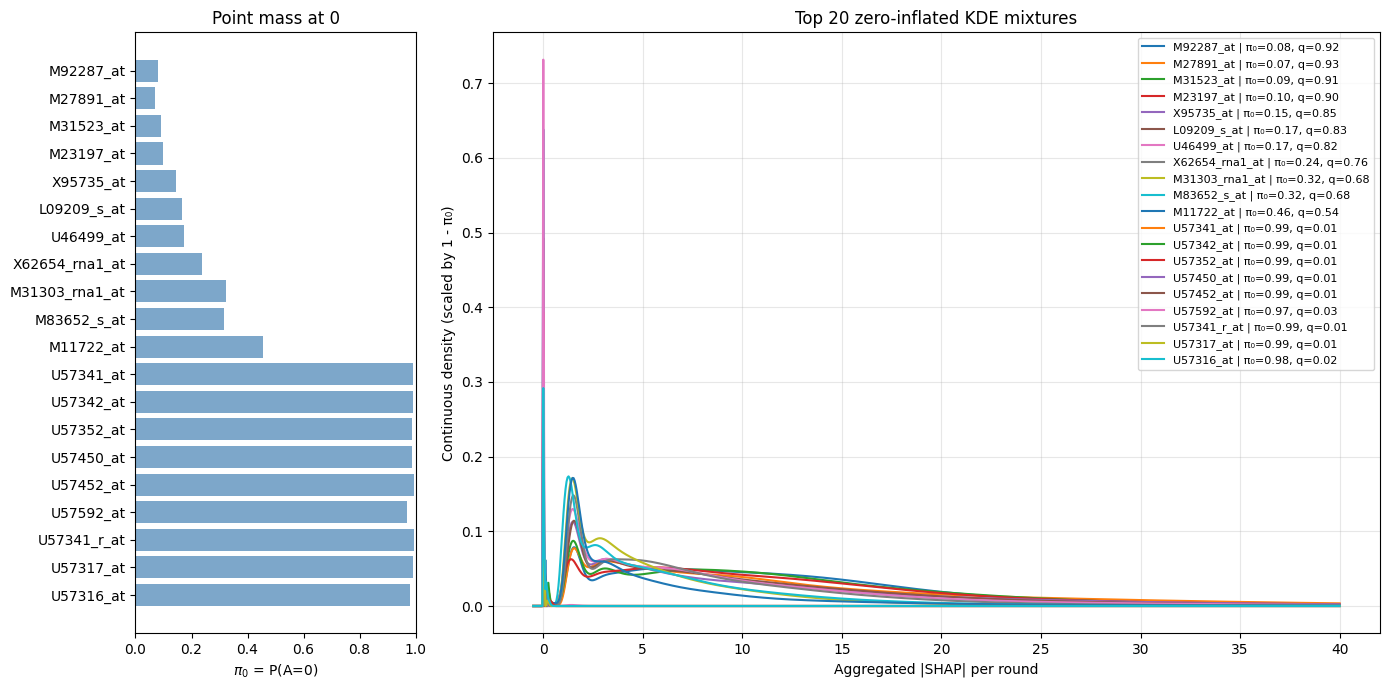

In [29]:
lgb_top = plot_top_feature_density(
    lgb_feature_kde_unscreen,
    top_k=20,
    score_col="median",
    x_min = -0.5,
    log_x=True,
    x_max=40
)

In [32]:
tmp = lgb_feature_kde_unscreen.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["nonzero_median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(6, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "Gene ID",
    "stat": "SHAP2",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,Gene ID,SHAP2,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,M92287_at,9.573,1.070,10.736,10.029,8.2%
2,M31523_at,8.979,1.057,10.276,9.719,9.0%
3,M23197_at,7.004,0.835,10.460,12.527,9.8%
4,M27891_at,5.825,0.653,10.338,15.819,7.0%
5,L09209_s_at,3.963,0.721,8.087,11.221,16.6%
6,U46499_at,3.162,0.667,7.402,11.104,17.5%


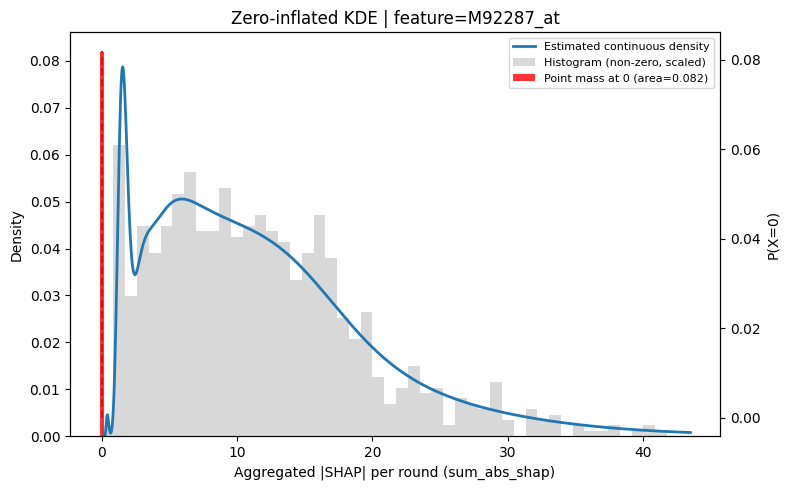

In [36]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=lgb_feature_kde_unscreen,
    boot_results=lgb_boot_unscreen,
    feature="M92287_at"
)

### Screening with |SHAP|

In [37]:
print("Training LightGBM model...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Create LightGBM datasets

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

Training LightGBM model...
Training set: (57, 7129)
Test set: (15, 7129)


Training LightGBM model and computing SHAP values for feature ranking...
✓ Model trained successfully
Computing SHAP values...
✓ SHAP values computed

Top 10 features by total |SHAP|:
       feature  total_abs_shap
     M31523_at       80.935989
     M92287_at       61.192081
     M55150_at       41.974629
     M27891_at       36.266126
     X95735_at       32.879984
X62654_rna1_at       30.302519
   L09209_s_at       29.945775
     M23197_at       28.518300
     X07743_at       14.169467
     M63379_at       13.470736


Evaluating LightGBM performance with SHAP-based feature selection...
✓ 0.01% (1 features): Acc=0.8667, F1=0.8500, AUC(macro)=0.9700
✓ 0.05% (3 features): Acc=0.8667, F1=0.8500, AUC(macro)=0.9400
✓ 0.1% (7 features): Acc=0.9333, F1=0.9206, AUC(macro)=1.0000
✓ 0.5% (35 features): Acc=1.0000, F1=1.0000, AUC(macro)=1.0000
✓ 1% (71 features): Acc=1.0000, F1=1.0000, AUC(macro)=1.0000
✓ 10% (712 features): Acc=1.0000, F1=1.0000, AUC(macro)=1.0000
✓ 100% (7129 features): Acc=1

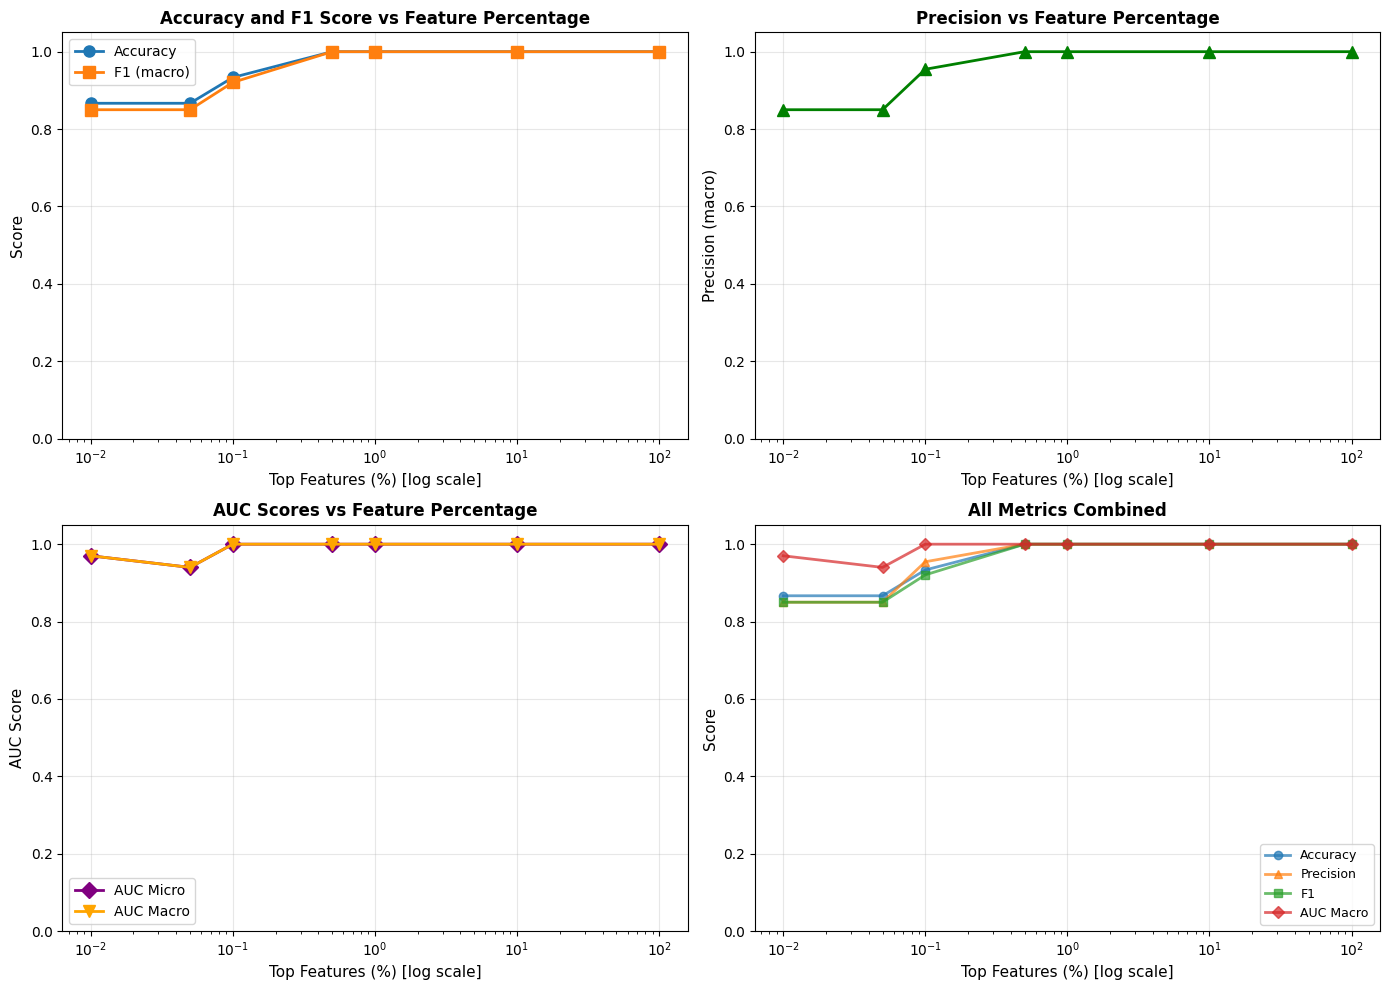


RESULTS TABLE (LightGBM SHAP-based Feature Selection):
 Percentage  N_Features  Accuracy  Precision (macro)  F1 (macro)  AUC Micro  AUC Macro
       0.01           1  0.866667           0.850000    0.850000       0.97       0.97
       0.05           3  0.866667           0.850000    0.850000       0.94       0.94
       0.10           7  0.933333           0.954545    0.920635       1.00       1.00
       0.50          35  1.000000           1.000000    1.000000       1.00       1.00
       1.00          71  1.000000           1.000000    1.000000       1.00       1.00
      10.00         712  1.000000           1.000000    1.000000       1.00       1.00
     100.00        7129  1.000000           1.000000    1.000000       1.00       1.00

✓ LightGBM SHAP-based feature selection analysis complete!


In [40]:
# Train LightGBM model to compute SHAP-based feature rankings
print("Training LightGBM model and computing SHAP values for feature ranking...")
print("=" * 70)

# Train LightGBM model on training data
lgb_ranking_model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    num_leaves=31,
    n_estimators=100,
    random_state=42,
    verbose=-1
)

lgb_ranking_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Compute SHAP values using LightGBM's built-in method
print("Computing SHAP values...")

# Get SHAP contributions directly from LightGBM (includes bias term as last column)
shap_contribs_lgb = lgb_ranking_model.predict(
    X_train, 
    pred_contrib=True
)

# For binary LightGBM: shape is (n_samples, n_features + 1)
# Add class axis so downstream code can keep the same reduction pattern.
n_samples = X_train.shape[0]
n_features = X_train.shape[1]

if shap_contribs_lgb.ndim == 2:
    shap_contribs_reshaped = shap_contribs_lgb[:, np.newaxis, :]
else:
    # Fallback for multiclass outputs if labels become >2 again.
    n_classes = len(lgb_ranking_model.classes_)
    shap_contribs_reshaped = shap_contribs_lgb.reshape(n_samples, n_classes, n_features + 1)

# Remove bias (last column) and sum |SHAP| across samples and classes
shap_values_only_lgb = shap_contribs_reshaped[:, :, :-1]  # Remove bias column
total_abs_shap_lgb = np.abs(shap_values_only_lgb).sum(axis=(0, 1))

print("✓ SHAP values computed")

# Create feature ranking dataframe
lgb_shap_feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'total_abs_shap': total_abs_shap_lgb
}).sort_values('total_abs_shap', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features by total |SHAP|:")
print(lgb_shap_feature_ranking.head(10).to_string(index=False))
print()

# Run performance evaluation using SHAP-based rankings
print("\n" + "=" * 70)
print("Evaluating LightGBM performance with SHAP-based feature selection...")
print("=" * 70)

lgb_shap_perf_table, lgb_shap_perf_fig = evaluate_top_features_performance(
    results_df=lgb_shap_feature_ranking,
    model_class=lgb.LGBMClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train = y_train,
    y_test=y_test,
    percentages=[0.01, 0.05, 0.1, 0.5, 1, 10, 100],
    ranking_col='total_abs_shap',  # Use SHAP sum instead of mean_A
    model_params={
        'objective': 'binary',
        'learning_rate': 0.1,
        'num_leaves': 31,
        'n_estimators': 100,
        'random_state': 42,
        'verbose': -1
    },
    log_x=True  # Enable log scale on x-axis
)

print("\n" + "=" * 70)
print("RESULTS TABLE (LightGBM SHAP-based Feature Selection):")
print("=" * 70)
print(lgb_shap_perf_table.to_string(index=False))
print("\n✓ LightGBM SHAP-based feature selection analysis complete!")

### Bootstrap after screening

In [41]:
X_screened_lgb = X[lgb_shap_feature_ranking['feature'].head(35)]

X_train, X_test, y_train, y_test = train_test_split(X_screened_lgb, y, test_size=0.2, random_state=42, stratify=y)

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

In [42]:
# lgb_boot_results = boot_multi_repeat_inference_keep_all(
lgb_boot_results = boot_multi_repeat_inference_keep_feature(
    X=X_screened_lgb,  # Use preprocessed data with one-hot encoded categoricals
    y=y,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

print(f"\nBootstrap complete! Generated {len(lgb_boot_results)} results.")

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [00:08<00:00, 118.94it/s]


Bootstrap complete! Generated 1000 results.


In [43]:
# lgb_mix = estimate_sample_feature_distribution(lgb_boot_results)

In [44]:
# top_df = plot_sample_top_features_overlay(
#     mix_df=lgb_mix,
#     sample_id=0,
#     class_id=None,  # or class index for multiclass
#     top_k=15,
#     rank_by="mean_abs_estimated",
#     n_grid=600,
#     xlim=(-2, 4)
# )

In [45]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix,
#     sample_id=0,
#     feature="5102",
#     # feature="M55150_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [46]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix,
#     sample_id=0,
#     feature="4519",
#     # feature="M23197_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [47]:
# lgb_feature_kde = estimate_feature_level_mixture(
#     boot_results=lgb_boot_results,
#     kernel="gaussian",
#     zero_tol=1e-8
# )

In [48]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_results,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

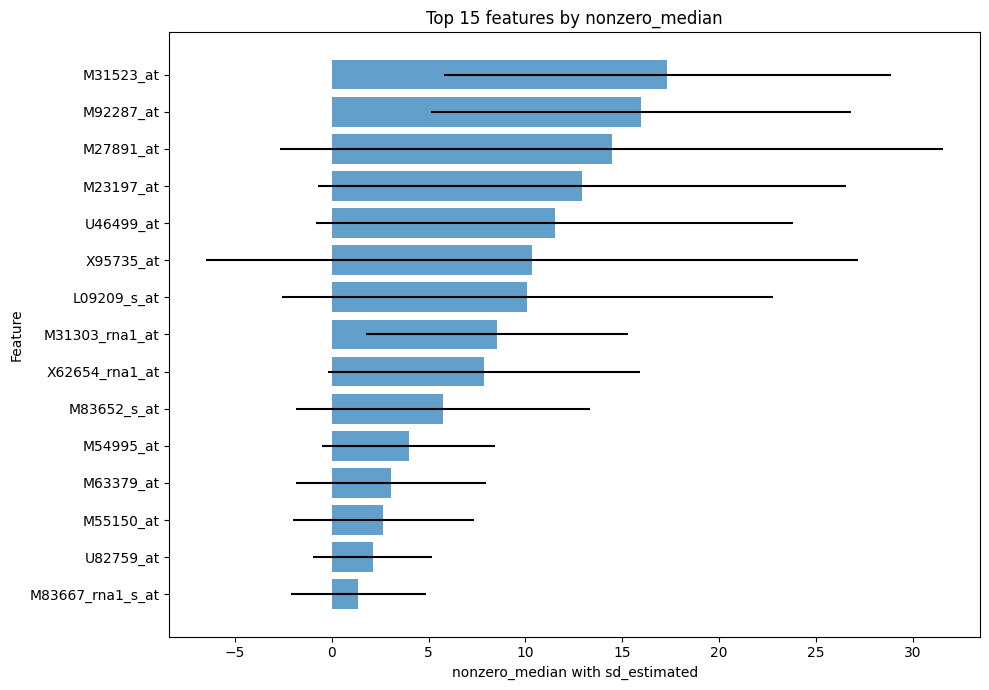

In [49]:
top_with_error = plot_top_feature_with_error(
    lgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
)

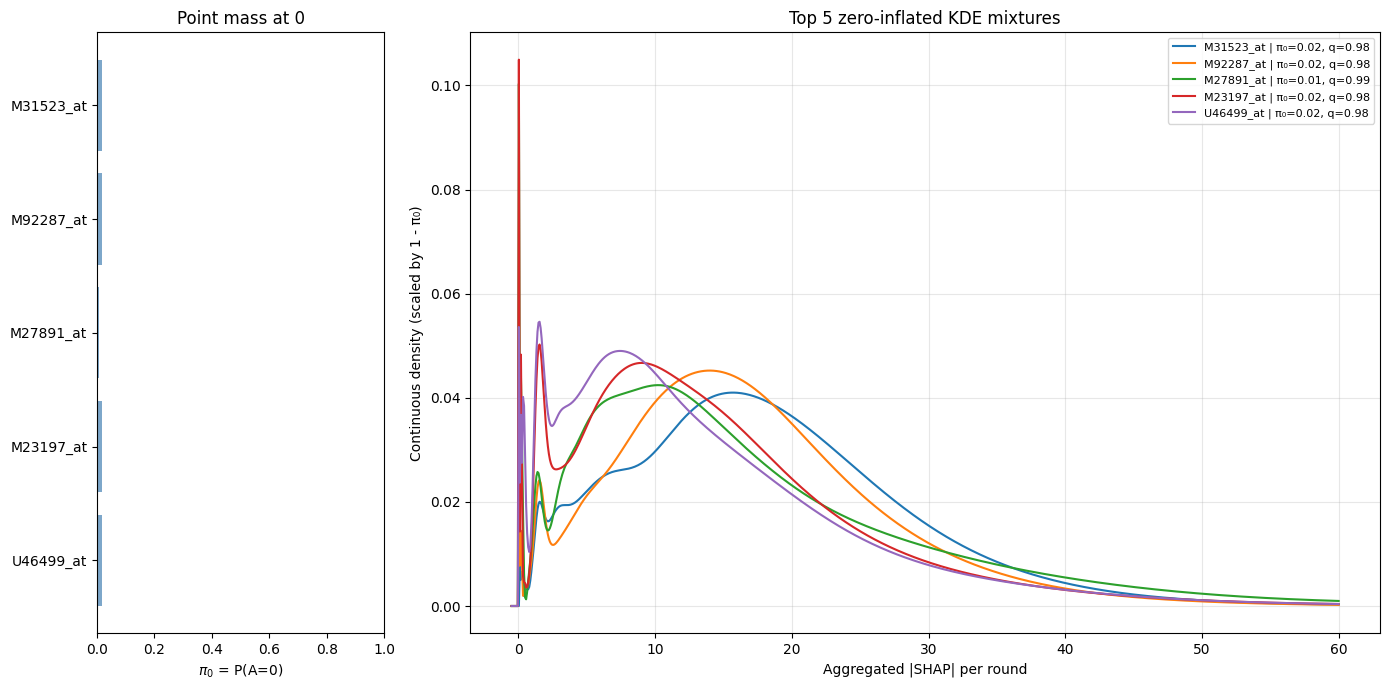

In [50]:
lgb_top = plot_top_feature_density(
    lgb_feature_kde,
    top_k=5,
    score_col="nonzero_median",
    x_min = -0.5,
    log_x=True,
    x_max=60
)

In [51]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["nonzero_median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(6, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "Gene ID",
    "stat": "SHAP2",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,Gene ID,SHAP2,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,M31523_at,25.607,1.512,17.425,11.527,1.9%
2,M92287_at,22.937,1.476,16.013,10.852,1.8%
3,M27891_at,11.747,0.833,14.251,17.117,0.6%
4,M23197_at,11.611,0.934,12.743,13.644,1.7%
5,U46499_at,9.930,0.910,11.207,12.317,1.6%
6,M31303_rna1_at,9.051,1.221,8.255,6.763,4.6%


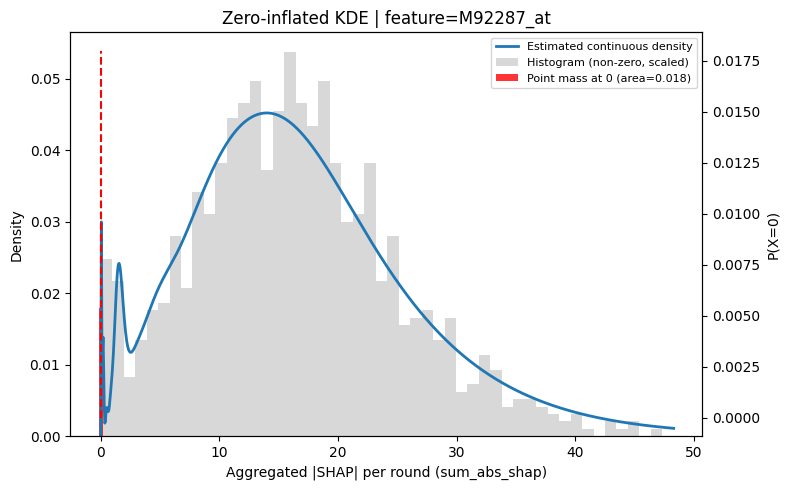

In [54]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=lgb_feature_kde,
    boot_results=lgb_boot_results,
    feature="M92287_at"
)

## XGBoost

In [56]:
seed = 42

xgb_params = {
        'objective': 'multi:softprob', # for multi-class classification
        'num_class': 3, # number of classes for multi-class classification
        'seed':seed, # random seed
        'eval_metric': 'mlogloss',  # multi-class logloss
        'eta': 0.5, # learning rate
        'max_depth': 10,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
            # Moderate regularization
        "lambda": 3.0,
        "alpha": 0.5,
       }

binary_params = {
    'objective': 'binary:logistic', # for binary classification
    'seed':seed, # random seed
    'eval_metric': 'logloss',  # binary logloss
    'eta': 0.1, # learning rate
    'max_depth': 6,
    'min_child_weight': 1,
    'subsample': 0.8, 
    'colsample_bytree': 0.6,
}

In [57]:
xgb_wrapper = create_model_wrapper(
    "xgboost",
    params=xgb_params,
    num_boost_round=15
)

### No screening

In [ ]:
# xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
#     X=X,  # Use preprocessed data with one-hot encoded categoricals
#     y=y,
#     inner_variance="permutation",
#     task="binary",
#     n_bootstrap=1000,  # Fewer bootstraps for speed with MLP
#     b_model=1,       # Fewer models per bootstrap
#     zero_tol=1e-8,
#     params=binary_params,
#     n_jobs=6,       
#     show_progress=True
# )

# print(f"\nBootstrap complete! Generated {len(xgb_boot_unscreen)} results.")

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [17:13<00:00,  1.03s/it] 


Bootstrap complete! Generated 1000 results.


In [ ]:
# # Save — concat all 1000 small DataFrames into one
# os.makedirs("shap_results", exist_ok=True)

# pd.concat(xgb_boot_unscreen, ignore_index=True).to_parquet(
#     "shap_results/golub_unscreen_xgb.parquet",
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet("shap_results/golub_unscreen_xgb.parquet")
xgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(xgb_boot_unscreen)} bootstrap results")

Saved!
Loaded 1000 bootstrap results


In [60]:
xgb_feature_kde_unscreen = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    zero_tol=1e-8
)

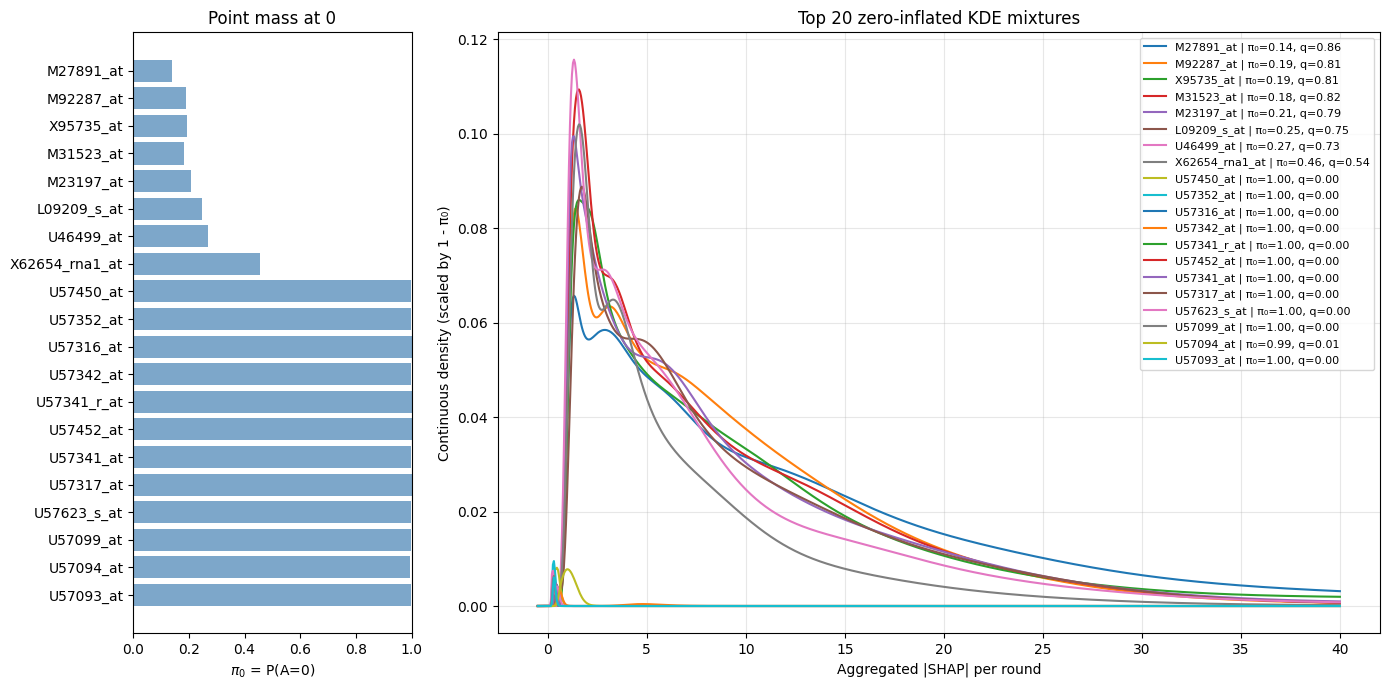

In [63]:
xgb_top = plot_top_feature_density(
    xgb_feature_kde_unscreen,
    top_k=20,
    score_col="median",
    x_min = -0.5,
    log_x=True,
    x_max=40
)

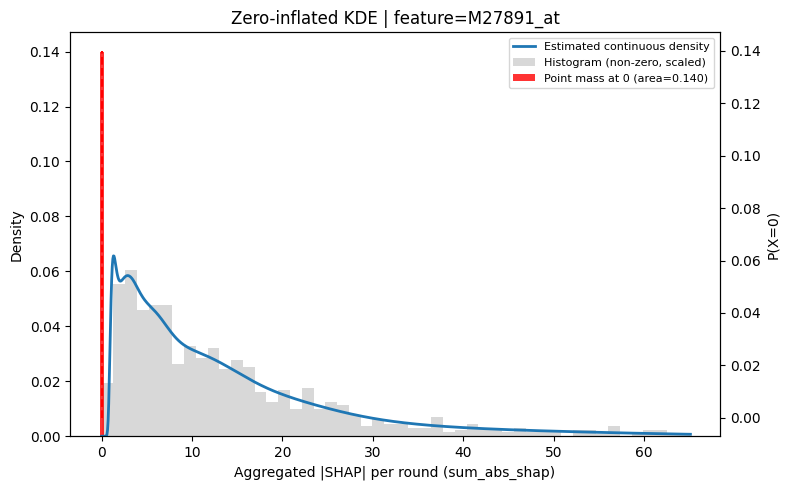

In [66]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=xgb_feature_kde_unscreen,
    boot_results=xgb_boot_unscreen,
    feature="M27891_at"
)

In [67]:
tmp = xgb_feature_kde_unscreen.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["nonzero_median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(6, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "Group",
    "stat": "SHAP2",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,Group,SHAP2,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,M27891_at,5.580,0.831,10.214,12.293,14.0%
2,M92287_at,4.682,0.943,8.019,8.503,18.9%
3,M31523_at,3.665,0.860,7.111,8.271,18.4%
4,X95735_at,3.207,0.673,8.132,12.085,19.3%
5,M23197_at,3.080,0.745,7.222,9.697,20.8%
6,L09209_s_at,2.997,0.804,7.192,8.950,24.7%


### Screening with |SHAP|

In [69]:
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
dtrain = xgb.DMatrix(X_xgb_train, label=y_xgb_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_xgb_test,  label=y_xgb_test,  enable_categorical=True)

Training XGBoost model and computing SHAP values for feature ranking...
Train/test split shapes:
  X_train: (57, 7129)
  X_test:  (15, 7129)
✓ Model trained successfully
Computing SHAP values on the training split...
✓ SHAP values computed

Top 20 features by total |SHAP|:
                  feature  total_abs_shap
                X95735_at       62.386177
                M31523_at       29.772274
                M92287_at       27.116526
                U46499_at       12.556821
                M27891_at       12.358768
              L09209_s_at       10.561232
                M55150_at        7.830144
                M23197_at        6.734736
           X62654_rna1_at        5.046245
                M63379_at        4.986388
              M83652_s_at        4.666849
                U82759_at        4.394368
                M11722_at        3.782522
           M96326_rna1_at        3.586392
         HG1612-HT1612_at        3.097142
                M54995_at        2.844711
            

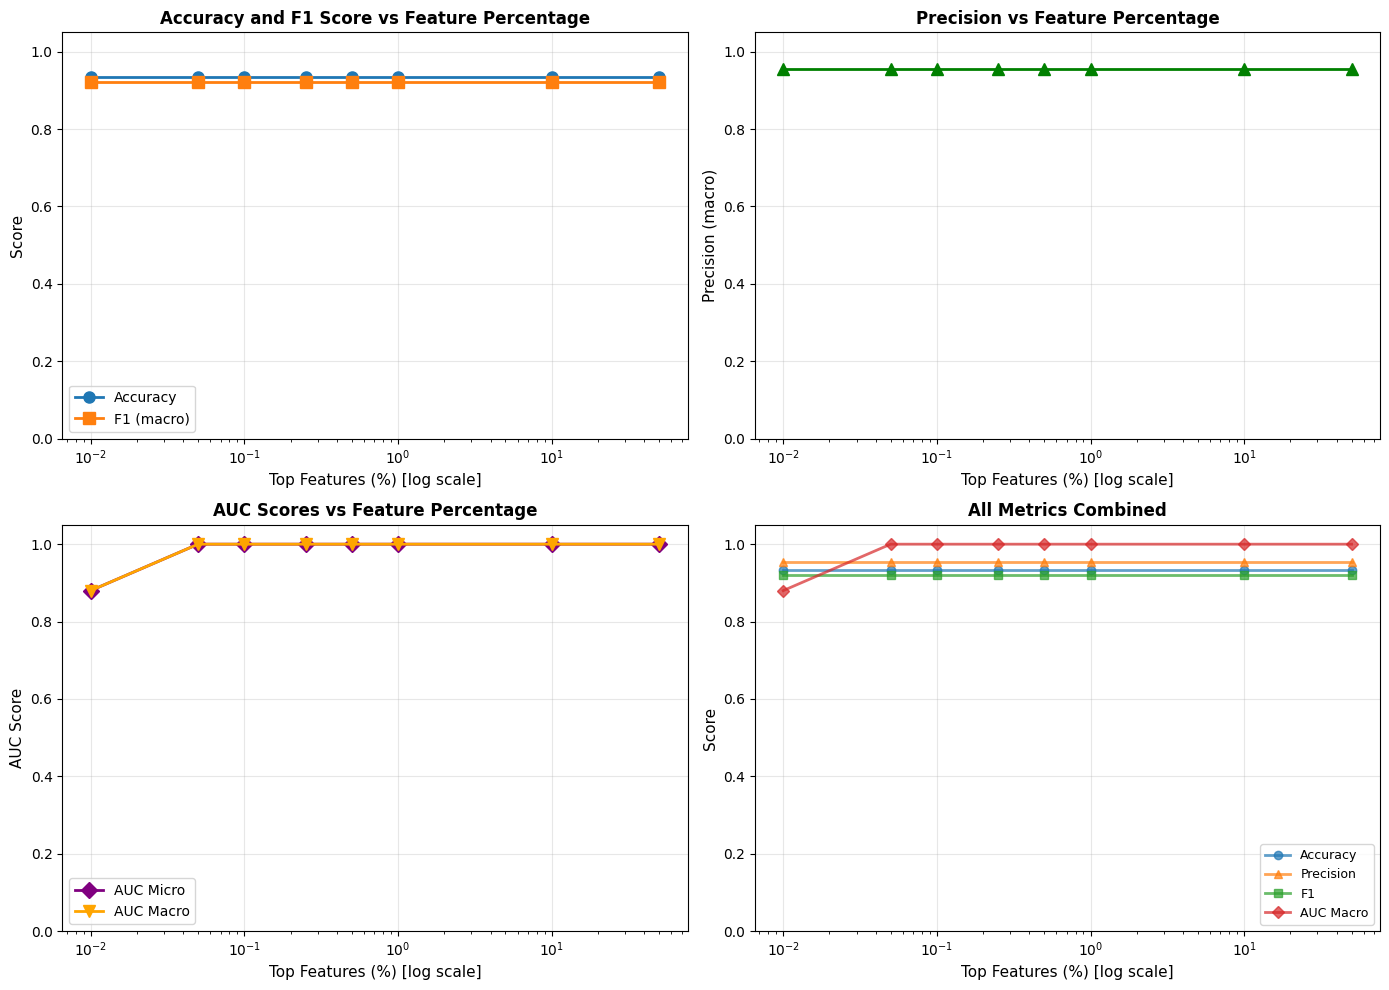


RESULTS TABLE (SHAP-based Feature Selection):
 Percentage  N_Features  Accuracy  Precision (macro)  F1 (macro)  AUC Micro  AUC Macro
       0.01           1  0.933333           0.954545    0.920635       0.88       0.88
       0.05           3  0.933333           0.954545    0.920635       1.00       1.00
       0.10           7  0.933333           0.954545    0.920635       1.00       1.00
       0.25          17  0.933333           0.954545    0.920635       1.00       1.00
       0.50          35  0.933333           0.954545    0.920635       1.00       1.00
       1.00          71  0.933333           0.954545    0.920635       1.00       1.00
      10.00         712  0.933333           0.954545    0.920635       1.00       1.00
      50.00        3564  0.933333           0.954545    0.920635       1.00       1.00

✓ SHAP-based feature selection analysis complete!


In [70]:
# Train XGBoost model to compute SHAP-based feature rankings without leakage
print("Training XGBoost model and computing SHAP values for feature ranking...")
print("=" * 70)

# Split once, then rank features on the training split only
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print("Train/test split shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

classes_xgb = np.sort(np.unique(y_train))
if len(classes_xgb) != 2:
    raise ValueError(f"This ranking cell is configured for binary XGBoost, got classes {classes_xgb}")

xgb_ranking_model = xgb.XGBClassifier(
    **binary_params,
    enable_categorical=True,
 )

# Fit on the training split only to avoid leakage
xgb_ranking_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Compute SHAP values on the training split only
print("Computing SHAP values on the training split...")
dtrain_rank = xgb.DMatrix(X_train, enable_categorical=True)

# Get SHAP contributions directly from XGBoost (includes bias term as last column)
shap_contribs = xgb_ranking_model.get_booster().predict(
    dtrain_rank,
    pred_contribs=True,
    strict_shape=True,
 )

# Binary XGBoost can return either:
#   (n_samples, n_features + 1)
# or with strict_shape:
#   (n_samples, 1, n_features + 1)
shap_contribs = np.asarray(shap_contribs)
if shap_contribs.ndim == 3:
    shap_values_only = shap_contribs[:, 0, :-1]
elif shap_contribs.ndim == 2:
    shap_values_only = shap_contribs[:, :-1]
else:
    raise ValueError(f"Unexpected SHAP contribution shape for binary XGBoost: {shap_contribs.shape}")

total_abs_shap = np.abs(shap_values_only).sum(axis=0)
print("✓ SHAP values computed")

# Create feature ranking dataframe
shap_feature_ranking = pd.DataFrame({
    "feature": X_train.columns,
    "total_abs_shap": total_abs_shap,
}).sort_values("total_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by total |SHAP|:")
print(shap_feature_ranking.head(20).to_string(index=False))
print()

# Run performance evaluation using held-out test data
print("\n" + "=" * 70)
print("Evaluating XGBoost performance with SHAP-based feature selection...")
print("=" * 70)

shap_perf_table, shap_perf_fig = evaluate_top_features_performance(
    results_df=shap_feature_ranking,
    model_class=xgb.XGBClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train=y_train,
    y_test=y_test,
    percentages=[0.01, 0.05, 0.1, 0.25, 0.5, 1, 10, 50],
    ranking_col="total_abs_shap",
    model_params=binary_params,
    log_x=True,
 )

print("\n" + "=" * 70)
print("RESULTS TABLE (SHAP-based Feature Selection):")
print("=" * 70)
print(shap_perf_table.to_string(index=False))
print("\n✓ SHAP-based feature selection analysis complete!")

In [71]:
X_xgb = X[shap_feature_ranking['feature'].head(31)]

### Bootstrap

In [72]:
xgb_boot_results = boot_multi_repeat_inference_keep_feature(
    X=X_xgb,  # Use preprocessed data with one-hot encoded categoricals
    y=y,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=1000,  # Fewer bootstraps for speed with MLP
    b_model=1,       # Fewer models per bootstrap
    zero_tol=1e-8,
    params=binary_params,
    n_jobs=6,       
    show_progress=True
)

print(f"\nBootstrap complete! Generated {len(xgb_boot_results)} results.")

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [00:10<00:00, 92.70it/s]


Bootstrap complete! Generated 1000 results.


In [95]:
# xgb_mix = estimate_sample_feature_distribution(xgb_boot_results)

In [96]:
# top_df = plot_sample_top_features_overlay(
#     mix_df=xgb_mix,
#     sample_id=0,
#     class_id=None,  # or class index for multiclass
#     top_k=15,
#     rank_by="mean_abs_estimated",
#     n_grid=600,
#     xlim=(-4, 2)
# )

In [97]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=xgb_mix,
#     sample_id=0,
#     feature="1776",
#     class_id=None,  # or None for binary/regression
#     boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     xlim=(-4, 2),
#     n_grid=800
# )

In [98]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=xgb_mix,
#     sample_id=0,
#     feature="35",
#     class_id=None,  # or None for binary/regression
#     boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [73]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_results,
    kernel="gaussian",
)

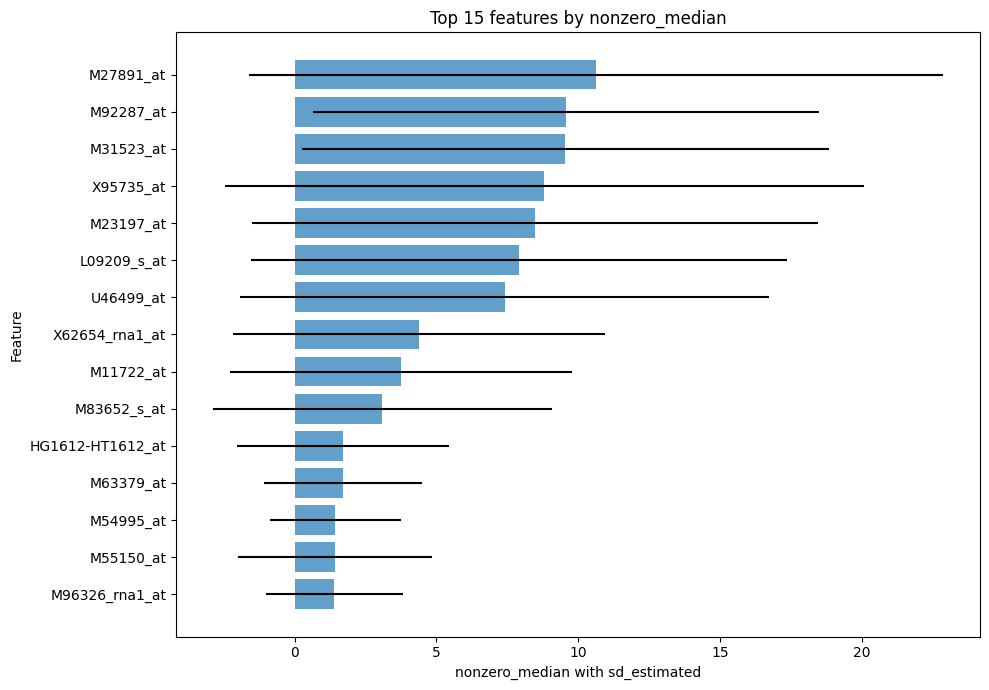

In [74]:
top_with_error = plot_top_feature_with_error(
    xgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
)

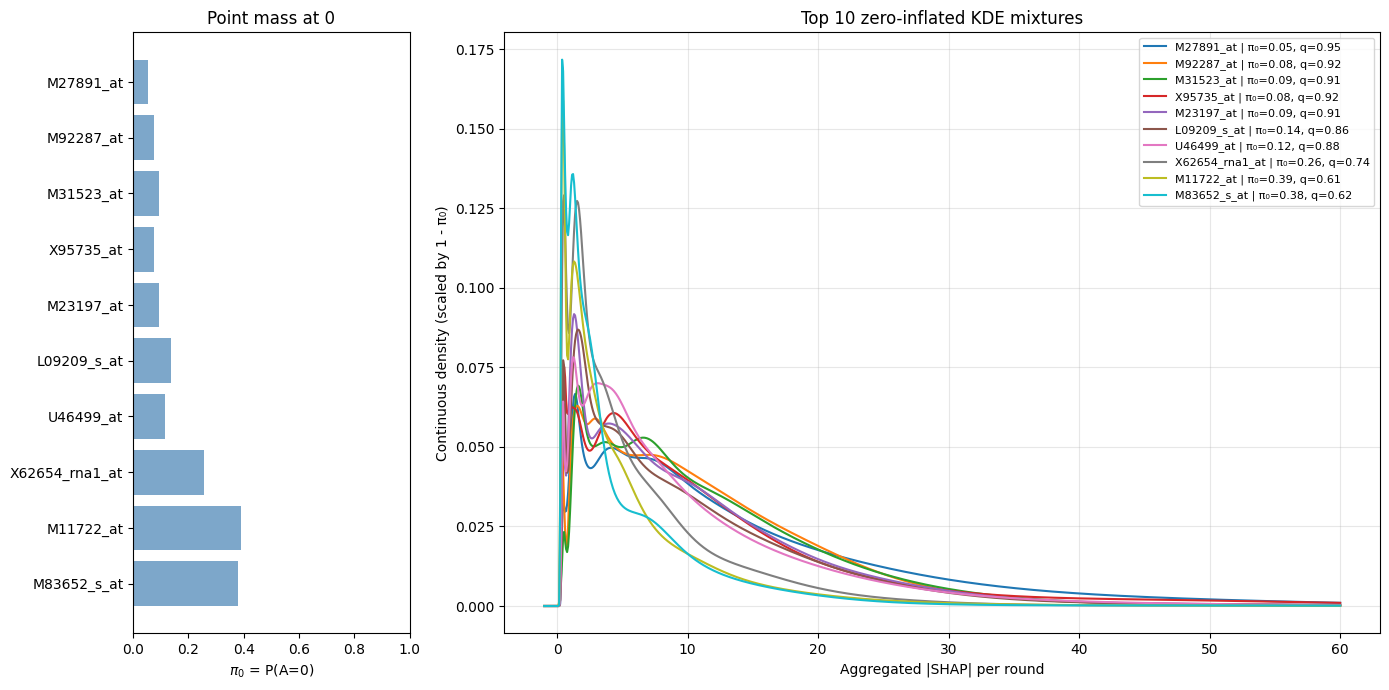

In [75]:
lgb_top = plot_top_feature_density(
    xgb_feature_kde,
    top_k=10,
    score_col="nonzero_median",
    x_min = -1,
    log_x=True,
    x_max=60
)

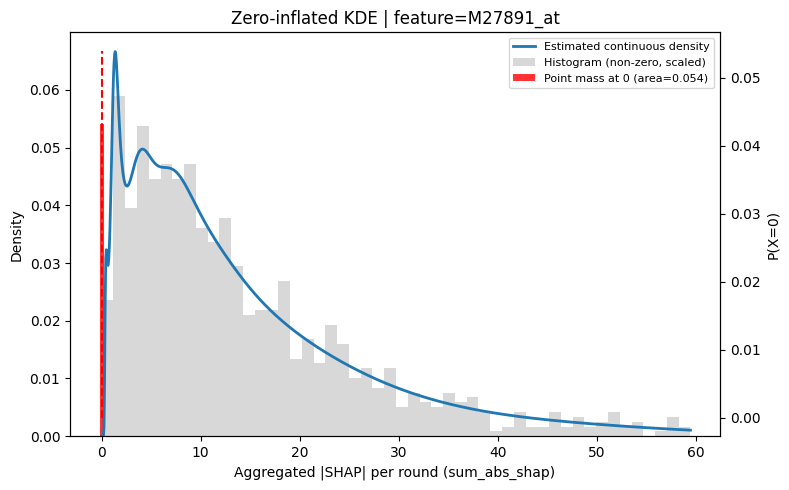

In [76]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=xgb_feature_kde,
    boot_results=xgb_boot_results,
    feature="M27891_at",
    bins = 50
)

In [77]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["nonzero_median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(6, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "Group",
    "stat": "SHAP2",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,Group,SHAP2,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,M92287_at,8.720,1.075,9.580,8.915,7.7%
2,M27891_at,8.317,0.883,10.821,12.249,5.4%
3,M31523_at,7.807,1.021,9.483,9.287,9.2%
4,X95735_at,5.918,0.792,8.921,11.261,7.6%
5,M23197_at,5.800,0.864,8.619,9.982,9.3%
6,L09209_s_at,4.666,0.867,8.195,9.451,13.7%


/tmp/ipykernel_1124581/1050506796.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


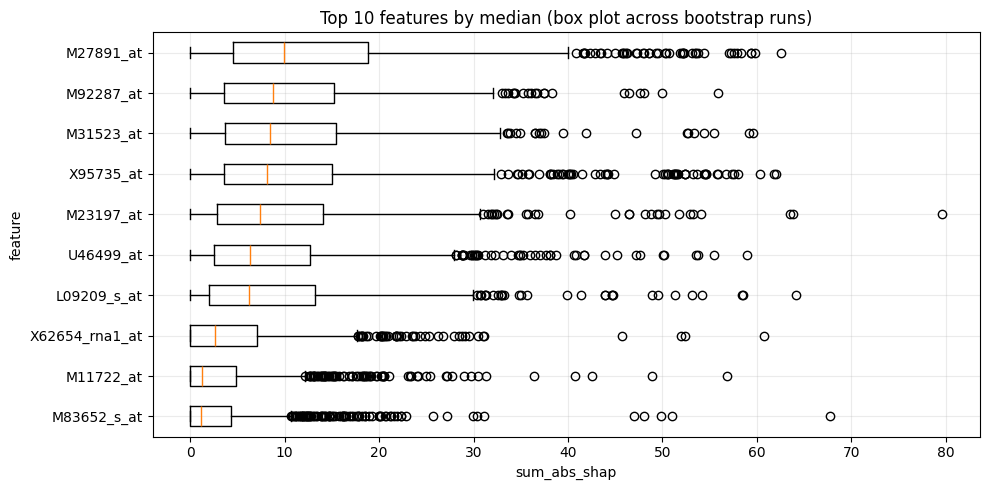

,feature,sum_abs_shap,bootstrap_id
0,L09209_s_at,2.852364,0
1,M11722_at,4.559309,0
2,M23197_at,10.013814,0
3,M27891_at,12.759014,0
4,M31523_at,18.902157,0


In [78]:
# Box plot for top features (run-level aggregated SHAP values)
top_k = 10
score_col = "median"   # ranking metric from xgb_feature_kde
agg_col = "sum_abs_shap"      # column in each element of xgb_boot_results

ranked = (
    xgb_feature_kde[["feature", score_col]]
    .dropna(subset=[score_col])
    .sort_values(score_col, ascending=False)
)

top_features = ranked["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(xgb_boot_results):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])

plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
plt.boxplot(
    plot_data,
    labels=top_features,
    vert=False,
    # showfliers=False,
    showfliers=True,
)
plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (box plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

box_df.head()

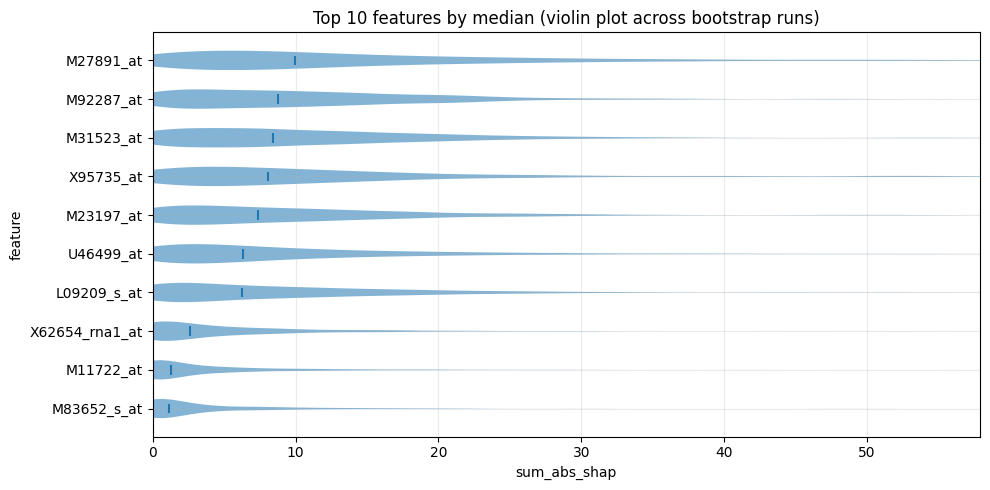

In [79]:
plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
vp = plt.violinplot(
    plot_data,
    vert=False,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in vp["bodies"]:
    body.set_alpha(0.55)

positions = np.arange(1, len(top_features) + 1)
plt.yticks(positions, top_features)

# robust x-axis (ignore extreme tail)
all_vals = np.concatenate(plot_data)
# x_lo = np.nanpercentile(all_vals, 1)
x_lo = 0
x_hi = np.nanpercentile(all_vals, 99.8)
plt.xlim(x_lo, x_hi)
plt.margins(x=0)

plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (violin plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature selection

In [202]:
xgb_feature_kde.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median
0,Source,2000,2000,24,1976,0.0120,0.2,gaussian,0.0,"{'pi_zero': 0.012, 'n_total': 2000, 'n_zero': ...",36.755948,36.755948,400.306932,20.007672,0.9880,0.022422,34.970405
1,1776,2000,2000,47,1953,0.0235,0.2,gaussian,0.0,"{'pi_zero': 0.0235, 'n_total': 2000, 'n_zero':...",30.496188,30.496188,371.344371,19.270298,0.9765,0.025241,28.138583
2,35,2000,2000,782,1218,0.3910,0.2,gaussian,0.0,"{'pi_zero': 0.391, 'n_total': 2000, 'n_zero': ...",5.046064,5.046064,68.332702,8.266360,0.6090,0.118660,4.648295
3,2597,2000,2000,663,1337,0.3315,0.2,gaussian,0.0,"{'pi_zero': 0.3315, 'n_total': 2000, 'n_zero':...",5.808859,5.808859,63.725332,7.982815,0.6685,0.088154,5.755813
4,3616,2000,2000,99,1901,0.0495,0.2,gaussian,0.0,"{'pi_zero': 0.0495, 'n_total': 2000, 'n_zero':...",21.425622,21.425622,327.674540,18.101783,0.9505,0.029988,18.682008


In [209]:
# Keep only unique cluster IDs that pass the threshold
xgb_selected_features = (
    xgb_feature_kde.loc[xgb_feature_kde['pi_zero'] < 0.05, 'feature']
    .astype(str)
    .drop_duplicates()
    .tolist()
)
xgb_selected_features

['Source', '1776', '3616', '2172']

In [210]:
for cluster in xgb_selected_features:
    if isinstance(cluster, str) and cluster.isdigit():
        cluster_id = int(cluster)
    else:
        continue

    genes = cluster_to_genes.get(cluster_id)
    if genes is None:
        continue

    var_exp = cluster_variance_explained.get(cluster_id, np.nan)
    print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
    print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")


Cluster 1776: 3 genes, Var explained: 0.7968
  Genes: M33680_at, U73737_at, Y08612_at

Cluster 3616: 5 genes, Var explained: 0.7635
  Genes: M92287_at, U94855_at, X15414_at, X59417_at, M31211_s_at

Cluster 2172: 7 genes, Var explained: 0.7691
  Genes: J04027_at, J04990_at, U46751_at, X07743_at, X62654_rna1_at, X90858_at, M13452_s_at


In [197]:
xgb_selected_features = shap_feature_ranking['feature'].head(10).tolist()

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X_grouped[xgb_selected_features], y, test_size=0.2, random_state=123, stratify=y)   

In [199]:
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [200]:
# Cross-validation on training data to find optimal parameters
num_rounds = 100  # number of iterations

# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    binary_params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "=" * 50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(
    f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} "
    f"(+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})"
)
print("=" * 50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.34290+0.01508	test-logloss:0.35419+0.05066
[1]	train-logloss:0.21403+0.01402	test-logloss:0.25000+0.05185
[2]	train-logloss:0.14332+0.01036	test-logloss:0.19836+0.06959
[3]	train-logloss:0.10278+0.00637	test-logloss:0.15709+0.06369
[4]	train-logloss:0.07778+0.00617	test-logloss:0.13147+0.06542
[5]	train-logloss:0.06062+0.00492	test-logloss:0.11852+0.07210
[6]	train-logloss:0.04921+0.00433	test-logloss:0.11036+0.07361
[7]	train-logloss:0.04050+0.00358	test-logloss:0.10152+0.07411
[8]	train-logloss:0.03385+0.00333	test-logloss:0.09647+0.07408
[9]	train-logloss:0.02900+0.00292	test-logloss:0.09300+0.07725
[10]	train-logloss:0.02532+0.00259	test-logloss:0.08691+0.07196
[11]	train-logloss:0.02246+0.00237	test-logloss:0.08637+0.07550
[12]	train-logloss:0.02009+0.00218	test-logloss:0.08363+0.07833
[13]	train-logloss:0.01838+0.00205	test-logloss:0.08199+0.08088
[14]	train-logloss:0.01675+0.00197	test-logloss:0.08158+0.0830

In [201]:
model = xgb.train(binary_params, dtrain, num_boost_round=best_num_rounds)
y_pred_proba = model.predict(dtest)

y_test_arr = np.asarray(y_test)
classes = np.sort(np.unique(y_train))

# Normalize probabilities to 2D so binary/multiclass paths are handled consistently.
if np.ndim(y_pred_proba) == 1:
    y_score_2d = np.column_stack([1 - y_pred_proba, y_pred_proba])
    y_pred = np.where(y_pred_proba >= 0.5, classes[-1], classes[0])
else:
    y_score_2d = np.asarray(y_pred_proba)
    if y_score_2d.shape[1] == 1:
        p = y_score_2d[:, 0]
        y_score_2d = np.column_stack([1 - p, p])

    pred_idx = np.argmax(y_score_2d, axis=1)
    y_pred = classes[pred_idx] if y_score_2d.shape[1] == len(classes) else pred_idx

# Compact metrics (package-based)
acc = accuracy_score(y_test_arr, y_pred)
print(f"Accuracy: {acc:.4f}")

if len(classes) == 2:
    positive_class = classes[-1]
    y_true_bin = (y_test_arr == positive_class).astype(int)
    auc_score = roc_auc_score(y_true_bin, y_score_2d[:, 1])
    print(f"ROC AUC: {auc_score:.4f}")
else:
    auc_score = roc_auc_score(y_test_arr, y_score_2d, multi_class="ovr", average="macro")
    print(f"ROC AUC (OvR macro): {auc_score:.4f}")

print("\nClassification report:")
print(classification_report(y_test_arr, y_pred, digits=4))

Accuracy: 1.0000
ROC AUC: 1.0000

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000         5

    accuracy                         1.0000        15
   macro avg     1.0000    1.0000    1.0000        15
weighted avg     1.0000    1.0000    1.0000        15

